In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
DATASET = "/kaggle/input/datasets/confirm/google-landmark-dataset-v2-micro/gldv2_micro"

IMAGE_DIR = os.path.join(DATASET, "images")

train_df = pd.read_csv(os.path.join(DATASET,"train.csv"))

In [3]:
top20 = train_df["landmark_id"].value_counts().head(20).index

train_df = train_df[train_df["landmark_id"].isin(top20)].reset_index(drop=True)

print(train_df.shape)

(161, 2)


In [4]:
train_df["filepath"] = train_df["filename"].apply(
    lambda x: os.path.join(IMAGE_DIR,x)
)

In [5]:
encoder = LabelEncoder()

train_df["label"] = encoder.fit_transform(train_df["landmark_id"])

NUM_CLASSES = train_df["label"].nunique()

print(NUM_CLASSES)

20


In [6]:
train_paths,val_paths,train_labels,val_labels = train_test_split(

train_df["filepath"],
train_df["label"],
test_size=0.2,
random_state=42,
stratify=train_df["label"]

)

In [7]:
IMG_SIZE=224
BATCH_SIZE=32

def load_image(path,label):

    image=tf.io.read_file(path)

    image=tf.image.decode_jpeg(image,channels=3)

    image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))

    image=preprocess_input(image)

    return image,label

In [8]:
train_ds=tf.data.Dataset.from_tensor_slices((train_paths,train_labels))
val_ds=tf.data.Dataset.from_tensor_slices((val_paths,val_labels))

AUTOTUNE=tf.data.AUTOTUNE

train_ds=train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds=val_ds.map(load_image).batch(BATCH_SIZE).prefetch(AUTOTUNE)

I0000 00:00:1784368195.329336      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784368195.332427      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
early = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early]
)

Epoch 1/10


2026-07-18 09:50:12.754395: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-18 09:50:12.890704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1784368215.603402      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0260 - loss: 3.4181

2026-07-18 09:50:28.683794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-18 09:50:28.817469: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.0391 - loss: 3.3064 - val_accuracy: 0.2424 - val_loss: 2.5939
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.1797 - loss: 2.7627 - val_accuracy: 0.3030 - val_loss: 2.4462
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.3125 - loss: 2.2701 - val_accuracy: 0.3939 - val_loss: 2.2791
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.3516 - loss: 2.2136 - val_accuracy: 0.5152 - val_loss: 2.0660
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.4453 - loss: 1.9630 - val_accuracy: 0.6061 - val_loss: 1.8499
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.5156 - loss: 1.6076 - val_accuracy: 0.6061 - val_loss: 1.6359
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6016 - loss: 1.4666 - val_accuracy: 0.6667 - val_loss: 1.4646
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.6953 - loss: 1.1992 - val_accuracy: 0.7273 - val_loss: 1.2987
Epoch 9/1

In [13]:
loss,acc=model.evaluate(val_ds)

print("Validation Accuracy :",acc*100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6970 - loss: 1.0847
Validation Accuracy : 69.69696879386902


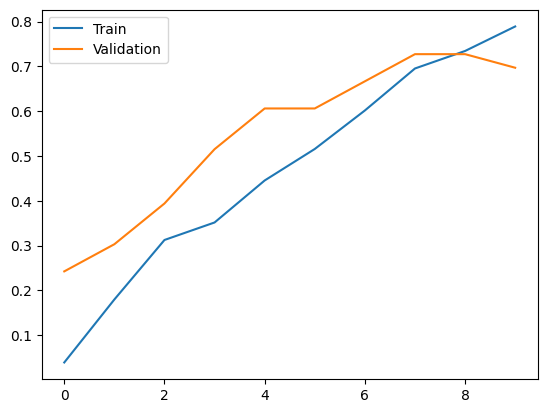

In [14]:
plt.plot(history.history["accuracy"],label="Train")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


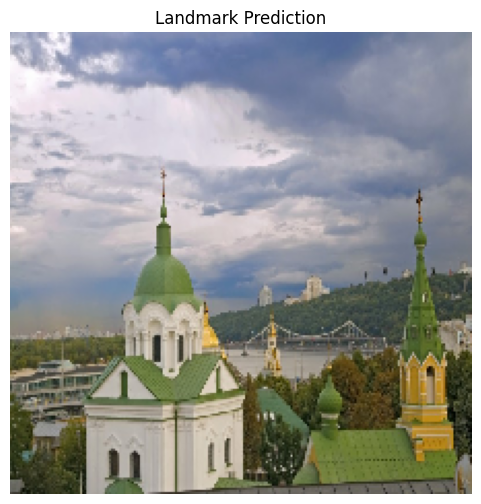

Actual Landmark ID    : 1078
Predicted Landmark ID : 1078
Confidence            : 48.36%


In [15]:
sample = train_df.sample(1).iloc[0]

img = tf.keras.preprocessing.image.load_img(
    sample["filepath"],
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

pred = np.argmax(prediction)

confidence = np.max(prediction) * 100

actual_id = sample["landmark_id"]
predicted_id = encoder.inverse_transform([pred])[0]

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Landmark Prediction")
plt.show()

print("="*40)
print("Actual Landmark ID    :", actual_id)
print("Predicted Landmark ID :", predicted_id)
print("Confidence            : {:.2f}%".format(confidence))
print("="*40)

In [16]:
model.save("LandmarkRecognition_MobileNetV2.keras")